# 01 — Black–Scholes utilities and calibration grids

This notebook begins the Dupire local-volatility project.

We will:

1. connect the notebook to the reusable code inside `src/`;
2. validate Black–Scholes call and put prices;
3. recover implied volatility from a price;
4. calculate forwards and log-moneyness;
5. construct the first calibration grid;
6. verify the surface-flattening convention used later by the inverse problem.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# This cell works whether Jupyter starts in the project root or notebooks folder.
project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)
print("Python executable:", sys.executable)


Project root: /mnt/data/dupire_audit/dupire_local_vol_project
Python executable: /opt/pyvenv/bin/python3


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.pricing.black_scholes import (
    black_scholes_call,
    black_scholes_put,
    black_scholes_vega,
    forward_price,
    implied_volatility_call,
)
from src.surfaces.grids import (
    log_moneyness_to_strike,
    make_calibration_grid,
    strike_to_log_moneyness,
    surface_to_vector,
    vector_to_surface,
)


## 1. Black–Scholes sanity check

For \(S_0=100\), \(K=100\), \(T=1\), \(r=5\%\), and \(\sigma=20\%\), the
standard Black–Scholes call value is approximately \(10.4506\).


In [3]:
spot = 100.0
strike = 100.0
maturity = 1.0
rate = 0.05
volatility = 0.20
dividend_yield = 0.0

call_price = black_scholes_call(
    spot=spot,
    strike=strike,
    maturity=maturity,
    rate=rate,
    volatility=volatility,
    dividend_yield=dividend_yield,
)

print(f"Call price: {call_price:.10f}")
assert np.isclose(call_price, 10.450583572185565, atol=1e-10)
print("Reference-value test passed.")


Call price: 10.4505835722
Reference-value test passed.


## 2. Put–call parity

The functions should satisfy

$$
C-P=S_0e^{-qT}-Ke^{-rT}.
$$


In [4]:
put_price = black_scholes_put(
    spot=spot,
    strike=strike,
    maturity=maturity,
    rate=rate,
    volatility=volatility,
    dividend_yield=dividend_yield,
)

parity_error = (
    call_price
    - put_price
    - spot * np.exp(-dividend_yield * maturity)
    + strike * np.exp(-rate * maturity)
)

print(f"Put price: {put_price:.10f}")
print(f"Put-call parity error: {parity_error:.3e}")
assert abs(parity_error) < 1e-10


Put price: 5.5735260223
Put-call parity error: 0.000e+00


## 3. Vectorised option prices

A single local-volatility model must price many strikes and maturities. We
therefore verify that the Black–Scholes function accepts arrays.


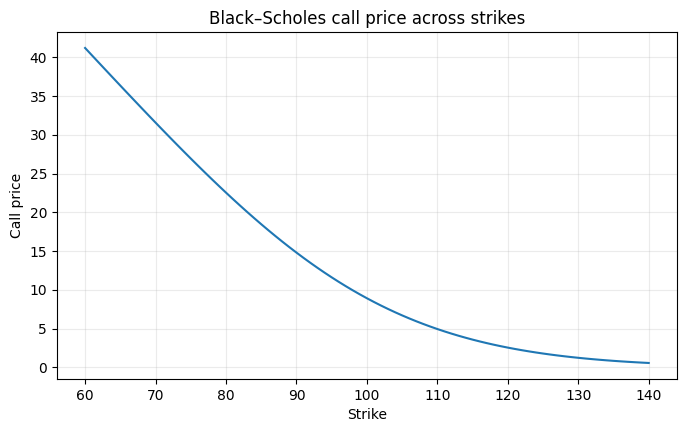

In [5]:
strike_grid = np.linspace(60.0, 140.0, 81)

call_curve = black_scholes_call(
    spot=100.0,
    strike=strike_grid,
    maturity=1.0,
    rate=0.02,
    volatility=0.20,
    dividend_yield=0.0,
)

plt.figure(figsize=(8, 4.5))
plt.plot(strike_grid, call_curve)
plt.xlabel("Strike")
plt.ylabel("Call price")
plt.title("Black–Scholes call price across strikes")
plt.grid(alpha=0.25)
plt.show()


## 4. Implied-volatility inversion

We first generate a price using a known volatility and then recover that
volatility from the price.


In [6]:
true_volatility = 0.31

market_price = black_scholes_call(
    spot=100.0,
    strike=110.0,
    maturity=0.75,
    rate=0.02,
    volatility=true_volatility,
    dividend_yield=0.01,
)

recovered_volatility = implied_volatility_call(
    market_price=market_price,
    spot=100.0,
    strike=110.0,
    maturity=0.75,
    rate=0.02,
    dividend_yield=0.01,
)

print(f"True volatility:      {true_volatility:.8f}")
print(f"Recovered volatility: {recovered_volatility:.8f}")
assert np.isclose(recovered_volatility, true_volatility, atol=1e-10)


True volatility:      0.31000000
Recovered volatility: 0.31000000


## 5. Forward price and log-moneyness

We use

$$
F(T)=S_0e^{(r-q)T},
\qquad
x=\log\left(\frac{K}{F(T)}\right).
$$

At-the-money forward corresponds to \(x=0\).


In [7]:
maturities = np.array([0.25, 0.50, 1.00, 2.00])
forwards = forward_price(
    spot=100.0,
    maturity=maturities,
    rate=0.03,
    dividend_yield=0.01,
)

atm_log_moneyness = strike_to_log_moneyness(
    strike=forwards,
    forward=forwards,
)

print("Maturities:", maturities)
print("Forwards:", np.round(forwards, 6))
print("ATM-forward log-moneyness:", atm_log_moneyness)

assert np.allclose(atm_log_moneyness, 0.0)


Maturities: [0.25 0.5  1.   2.  ]
Forwards: [100.501252 101.005017 102.020134 104.081077]
ATM-forward log-moneyness: [0. 0. 0. 0.]


In [8]:
example_strikes = np.array([80.0, 100.0, 120.0])
example_forward = 100.0

x_values = strike_to_log_moneyness(example_strikes, example_forward)
restored_strikes = log_moneyness_to_strike(x_values, example_forward)

print("Strikes:", example_strikes)
print("Log-moneyness:", np.round(x_values, 6))
print("Restored strikes:", np.round(restored_strikes, 6))

assert np.allclose(example_strikes, restored_strikes)


Strikes: [ 80. 100. 120.]
Log-moneyness: [-0.223144  0.        0.182322]
Restored strikes: [ 80. 100. 120.]


## 6. Calibration grid

Our local-volatility surface will be stored with shape

```text
(number of maturities, number of log-moneyness points)
```

Rows are maturities and columns are log-moneyness points.


In [9]:
x_grid, maturity_grid, x_mesh, maturity_mesh = make_calibration_grid(
    x_lower=-0.4,
    x_upper=0.4,
    number_of_x_points=25,
    maturity_lower=0.05,
    maturity_upper=2.0,
    number_of_maturity_points=15,
)

print("x-grid shape:", x_grid.shape)
print("maturity-grid shape:", maturity_grid.shape)
print("surface shape:", x_mesh.shape)


x-grid shape: (25,)
maturity-grid shape: (15,)
surface shape: (15, 25)


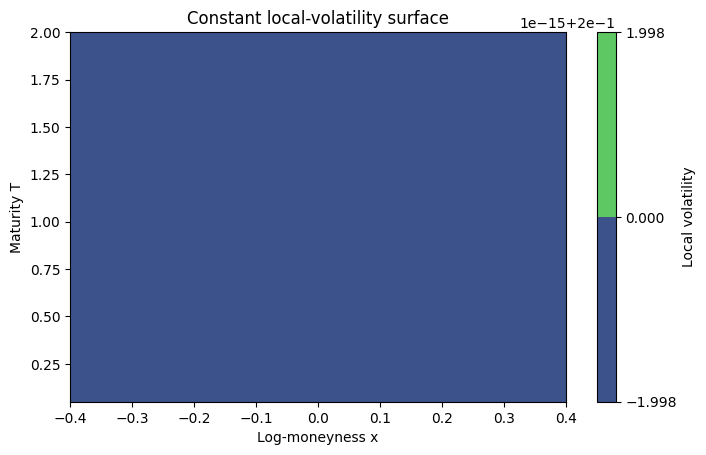

In [10]:
constant_volatility_surface = np.full_like(x_mesh, 0.20)

plt.figure(figsize=(8, 4.8))
contour = plt.contourf(
    x_grid,
    maturity_grid,
    constant_volatility_surface,
    levels=20,
)
plt.colorbar(contour, label="Local volatility")
plt.xlabel("Log-moneyness x")
plt.ylabel("Maturity T")
plt.title("Constant local-volatility surface")
plt.show()


## 7. Surface flattening convention

The inverse problem will represent the two-dimensional surface as one vector.
We flatten row by row, so log-moneyness varies fastest within each maturity.


In [11]:
small_surface = np.array(
    [
        [1.0, 2.0, 3.0],
        [4.0, 5.0, 6.0],
    ]
)

surface_vector = surface_to_vector(small_surface)
restored_surface = vector_to_surface(
    surface_vector,
    number_of_maturity_points=2,
    number_of_x_points=3,
)

print("Original surface:")
print(small_surface)
print("\nFlattened vector:")
print(surface_vector)
print("\nRestored surface:")
print(restored_surface)

assert np.array_equal(small_surface, restored_surface)


Original surface:
[[1. 2. 3.]
 [4. 5. 6.]]

Flattened vector:
[1. 2. 3. 4. 5. 6.]

Restored surface:
[[1. 2. 3.]
 [4. 5. 6.]]


## 8. Vega check

Vega measures the sensitivity of an option price to volatility. It will later
help us understand weighting and price sensitivity.


In [12]:
vega = black_scholes_vega(
    spot=100.0,
    strike=100.0,
    maturity=1.0,
    rate=0.02,
    volatility=0.20,
)

print(f"ATM one-year vega: {vega:.6f}")
assert vega > 0


ATM one-year vega: 39.104269


## Stage 1 result

We now have:

- validated Black–Scholes call and put pricing;
- implied-volatility inversion;
- forward-price and log-moneyness conversion;
- a fixed calibration-grid orientation;
- a tested flattening convention.

The next notebook will implement the finite-difference local-volatility PDE
pricer and verify that a constant local-volatility surface reproduces
Black–Scholes prices.
